# H3 — node2vec embeddings for the structural similarity graphs

## Purpose
Turns the graphs built in [`network_generation.ipynb`](./network_generation.ipynb) into fixed-length node embeddings using **node2vec**: it simulates biased random walks over each graph, then feeds those walks into a skip-gram (`word2vec`)-style model, so that drugs with similar network neighborhoods end up with similar embedding vectors.

Three graphs are loaded: two per-population graphs (`adverse_structural.graphml`, `non_interacting_structural.graphml`), kept to diagnose each population's topology and embedding quality in isolation, and one **combined** graph (`combined_structural.graphml`, built in `network_generation.ipynb` from the union of both populations) -- the combined-graph embedding is the canonical artifact any downstream classifier should use.

## Environment note
This environment now has both `pecanpy` and `gensim` installed and working, so `src/node2vec_utils.py` runs node2vec via `pecanpy`'s `SparseOTF` random-walk simulator + gensim's `Word2Vec` for the skip-gram training -- no compatibility shims needed. See [`../NODE2VEC_ENV_NOTES.md`](../NODE2VEC_ENV_NOTES.md) for the environment history.

## Pipeline
1. Load `adverse_structural.graphml` / `non_interacting_structural.graphml` / `combined_structural.graphml`.
2. Set node2vec hyperparameters.
3. Run node2vec on each of the two per-population graphs.
4. Sanity-check the embeddings (shape, a PCA scatter, nearest-neighbor spot check).
5. Save the two per-population embeddings to `embeddings/{dataset}_structural_node2vec.parquet`.

6. Quick analysis of embedding quality (edge-vs-random AUROC) for the two per-population graphs.7. Run node2vec on the combined graph and save the canonical embedding for downstream modeling.

## Glossary (plain-English definitions)

- **node2vec:** An algorithm that converts each node in a graph into a list of numbers (an *embedding*) by simulating many random walks starting from that node, then training a `word2vec`-style model to predict "which nodes tend to co-occur on the same walk" -- nodes that show up in similar neighborhoods end up with similar vectors.
- **Random walk:** Starting at a node, repeatedly hop to a random neighbor (weighted by edge weight) for a fixed number of steps, recording the sequence of nodes visited.
- **`p` (return parameter):** Controls how likely the walk is to immediately backtrack to the node it just came from. Higher `p` = less backtracking = more exploration.
- **`q` (in-out parameter):** Controls whether the walk prefers to stay close to the start node (behaving like breadth-first search, good for capturing local community structure) or wander further away (behaving like depth-first search, good for capturing structural roles). `q < 1` encourages wandering; `q > 1` encourages staying local.
- **`dimensions`:** The length of each drug's output embedding vector.
- **`walk_length` / `num_walks`:** How many steps each random walk takes, and how many walks are started from each node -- more walks/longer walks means more training data for the embedding model but more runtime.
- **`window`:** The skip-gram context window -- how many neighbors on either side of a node *within a walk* count as "co-occurring" with it.
- **Embedding:** A fixed-length numeric vector summarizing a node's position/role in the graph, suitable as input to a downstream ML model (e.g. a DDI classifier that concatenates two drugs' embeddings).

## How node2vec actually works here, step by step

1. **Simulate random walks.** Starting from every drug (node), take `num_walks` separate walks of `walk_length` steps each. At each step, hop to a random neighbor -- the chance of picking any particular neighbor is proportional to that edge's weight, further biased by `p`/`q` (see Glossary above). The result is a big pile of walks, where each walk is just a list of drug IDs, e.g. `["DB00001", "DB00035", "DB00080", ...]`.
2. **Treat walks like sentences.** Feed all those walks into a `word2vec` skip-gram model exactly the way you'd feed it sentences of words -- it learns to predict "which nodes tend to appear near this one within a walk," using a sliding `window`. Nodes that keep showing up in similar walk-contexts end up with similar vectors.
3. **Read off the embeddings.** Once training finishes, each node's `dimensions`-length vector *is* its node2vec embedding -- ready to save and later feed into a downstream DDI classifier.

## `pecanpy` vs. the PyPI `node2vec` package

Both implement the same algorithm (Grover & Leskovec's biased 2nd-order random walks + skip-gram), but they differ in maintenance status and implementation:

| | PyPI `node2vec` (0.3.0) | `pecanpy` (used in this notebook) |
|---|---|---|
| Maintenance | Unmaintained since ~2020 | Actively maintained |
| Walk simulation | Pure Python + joblib | Numba-JIT-compiled (`@njit`) -- substantially faster |
| gensim compatibility | Calls `Word2Vec(size=..., iter=...)`, which **breaks** on gensim >= 4.0 (renamed to `vector_size`/`epochs`) unless patched | Calls `Word2Vec(vector_size=..., epochs=...)` -- works natively on gensim >= 4.0, no patching needed |
| Graph representations | One (dense per-node neighbor lists) | Several: `PreComp` (precomputes and caches 2nd-order transition probabilities -- fastest for repeated walks, but memory-heavy), `SparseOTF`/`DenseOTF` ("on the fly" -- recompute transition probabilities during the walk itself, trading a little CPU time for much lower memory use) |

We use pecanpy's **`SparseOTF`** variant because these graphs are sparse (relatively few edges per node relative to the total node count) -- `SparseOTF` stores the graph as a CSR sparse matrix internally rather than a dense one. Note: our current loader (`src/node2vec_utils.py`) still builds a dense adjacency matrix via `networkx.to_numpy_array` as an intermediate step before handing it to pecanpy, which is fine at this project's scale (thousands of nodes) but would need to switch to pecanpy's `read_edg` (which reads a sparse edge-list file directly, no dense intermediate) if a future graph grew into the tens/hundreds of thousands of nodes.

See [`../NODE2VEC_ENV_NOTES.md`](../NODE2VEC_ENV_NOTES.md) for the environment-setup history behind this choice.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

SRC_FOLDER = r"C:\Users\ashto\ddi-prediction\src"
if SRC_FOLDER not in sys.path:
    sys.path.append(SRC_FOLDER)

from node2vec_utils import run_node2vec, save_embeddings

NETWORK_DIR = Path(r"C:\Users\ashto\ddi-prediction\notebooks\h3_structural_similarity\networks")
EMBEDDING_DIR = Path(r"C:\Users\ashto\ddi-prediction\notebooks\h3_structural_similarity\embeddings")
EMBEDDING_DIR.mkdir(exist_ok=True)

## 1. Load the graphs

In [2]:
DATASETS = ["adverse", "non_interacting"]
LAYER = "structural"

graphs = {}
for dataset in DATASETS:
    G = nx.read_graphml(NETWORK_DIR / f"{dataset}_{LAYER}.graphml")
    graphs[dataset] = G
    print(f"{dataset:<16}: {G.number_of_nodes():>5} nodes, {G.number_of_edges():>7} edges")

adverse         :  1893 nodes,   20776 edges
non_interacting :  1893 nodes,   20295 edges


## 2. node2vec hyperparameters

These match the defaults recommended in the original node2vec paper (Grover & Leskovec, 2016). `p = q = 1` reduces node2vec to plain unbiased random walks (a good, neutral starting point) -- retune `p`/`q` later if you want to bias the walks toward local community structure (`q < 1`) or exploration (`q > 1`).

In [2]:
NODE2VEC_PARAMS = dict(
    dimensions=128,
    walk_length=80,
    num_walks=10,
    p=1.0,
    q=1.0,
    window=10,
    epochs=5,
    workers=1,  # raise if parallel walk generation works fine on your machine
    seed=42,
)

## 3. Run node2vec

Simulates the random walks and trains the skip-gram model for each graph. This is the slow step -- expect this to take longer than everything else in the notebook combined.

In [4]:
structural_embeddings = {}
for dataset, G in graphs.items():
    print(f"Running node2vec on {dataset}...")
    structural_embeddings[dataset] = run_node2vec(G, **NODE2VEC_PARAMS)
    print(f"  -> embeddings shape: {structural_embeddings[dataset].shape}")

Running node2vec on adverse...
  -> embeddings shape: (1893, 128)
Running node2vec on non_interacting...
  -> embeddings shape: (1893, 128)


## 4. Sanity checks

A quick visual/spot check -- not a rigorous evaluation (that belongs in the downstream DDI modeling notebook). We check that:
- Every node in the graph got an embedding row.
- A 2D PCA projection doesn't collapse everything to a single point (which would signal a degenerate/failed training run).
- A random drug's nearest neighbors in embedding space look at least plausible (share edges or similar degree) rather than arbitrary.

adverse         : 0 node(s) missing an embedding (expect 0)
non_interacting : 0 node(s) missing an embedding (expect 0)


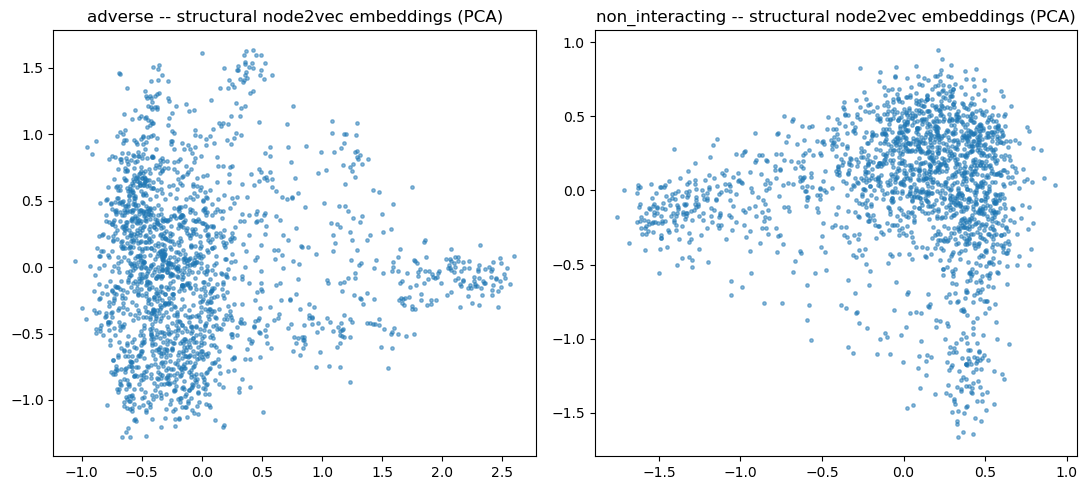

In [5]:
for dataset, G in graphs.items():
    n_missing = G.number_of_nodes() - structural_embeddings[dataset].shape[0]
    print(f"{dataset:<16}: {n_missing} node(s) missing an embedding (expect 0)")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (dataset, emb) in zip(axes, structural_embeddings.items()):
    coords = PCA(n_components=2, random_state=42).fit_transform(emb.values)
    ax.scatter(coords[:, 0], coords[:, 1], s=6, alpha=0.5)
    ax.set_title(f"{dataset} -- structural node2vec embeddings (PCA)")
plt.tight_layout()
plt.show()

In [6]:
dataset_to_check = "adverse"
G = graphs[dataset_to_check]
emb = structural_embeddings[dataset_to_check]

sample_node = max(G.degree, key=lambda x: x[1])[0]  # pick a well-connected node so its neighbors are informative
sims = cosine_similarity(emb.loc[[sample_node]], emb).flatten()
nearest = pd.Series(sims, index=emb.index).drop(sample_node).sort_values(ascending=False).head(5)

sample_name = G.nodes[sample_node].get("name", sample_node)
print(f"Nearest embedding neighbors of {sample_node} ({sample_name}):")
for neighbor_id, sim in nearest.items():
    is_graph_neighbor = G.has_edge(sample_node, neighbor_id)
    neighbor_name = G.nodes[neighbor_id].get("name", neighbor_id)
    print(f"  {neighbor_id} ({neighbor_name}): cosine_sim={sim:.3f}, direct graph edge={is_graph_neighbor}")

Nearest embedding neighbors of DB00296 (Ropivacaine):
  DB00297 (Bupivacaine): cosine_sim=0.808, direct graph edge=True
  DB00961 (Mepivacaine): cosine_sim=0.768, direct graph edge=True
  DB04786 (Suramin): cosine_sim=0.643, direct graph edge=True
  DB13164 (Olmutinib): cosine_sim=0.637, direct graph edge=True
  DB00634 (Sulfacetamide): cosine_sim=0.561, direct graph edge=True


## 5. Save embeddings

Each embedding table is written to `embeddings/{dataset}_structural_node2vec.parquet`, indexed by `drug_id`.

In [7]:
for dataset, emb in structural_embeddings.items():
    out_path = EMBEDDING_DIR / f"{dataset}_structural_node2vec.parquet"
    save_embeddings(emb, out_path)
    print(f"Saved {emb.shape} embedding table to {out_path}")

Saved (1893, 128) embedding table to C:\Users\ashto\ddi-prediction\notebooks\h3_structural_similarity\embeddings\adverse_structural_node2vec.parquet
Saved (1893, 128) embedding table to C:\Users\ashto\ddi-prediction\notebooks\h3_structural_similarity\embeddings\non_interacting_structural_node2vec.parquet


## 6. Quick analysis: did node2vec actually learn the graph structure?

The nearest-neighbor spot check in Section 4 was anecdotal (one drug). Here we check it systematically: node2vec's entire job is to make **connected** drugs end up with **similar embeddings**, so for each graph we compare the embedding cosine similarity of real edges against the same for random (mostly unconnected) drug pairs, and summarize the separation with an AUROC -- same style of check as the `auroc_ddi_prediction` diagnostic in `network_generation.ipynb`, but here scored against the graph's own edges rather than DDI labels. This is a check on the *embedding step itself*, not a claim about DDI predictiveness (that's for the downstream modeling notebook).

In [8]:
import numpy as np
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(42)
analysis_rows = []
similarity_samples = {}

for dataset, G in graphs.items():
    emb = structural_embeddings[dataset]
    node_ids = list(emb.index)
    id_to_idx = {node_id: i for i, node_id in enumerate(node_ids)}
    normed = emb.values / np.linalg.norm(emb.values, axis=1, keepdims=True)

    edges = list(G.edges())
    pos_sims = np.array([normed[id_to_idx[u]] @ normed[id_to_idx[v]] for u, v in edges])

    n_nodes = len(node_ids)
    neg_sims = []
    while len(neg_sims) < len(edges):
        i, j = rng.integers(0, n_nodes, size=2)
        if i == j:
            continue
        u, v = node_ids[i], node_ids[j]
        if G.has_edge(u, v):
            continue
        neg_sims.append(normed[i] @ normed[j])
    neg_sims = np.array(neg_sims)

    y_true = np.concatenate([np.ones(len(pos_sims)), np.zeros(len(neg_sims))])
    y_score = np.concatenate([pos_sims, neg_sims])

    similarity_samples[dataset] = (pos_sims, neg_sims)
    analysis_rows.append({
        "dataset": dataset,
        "n_nodes": n_nodes,
        "n_edges": len(edges),
        "mean_cos_sim_edges": pos_sims.mean(),
        "mean_cos_sim_random_pairs": neg_sims.mean(),
        "auroc_edge_vs_random": roc_auc_score(y_true, y_score),
    })

embedding_quality_df = pd.DataFrame(analysis_rows)
embedding_quality_df

,dataset,n_nodes,n_edges,mean_cos_sim_edges,mean_cos_sim_random_pairs,auroc_edge_vs_random
0,adverse,1893,20776,0.571182,0.159122,0.987002
1,non_interacting,1893,20295,0.426004,0.105847,0.995190


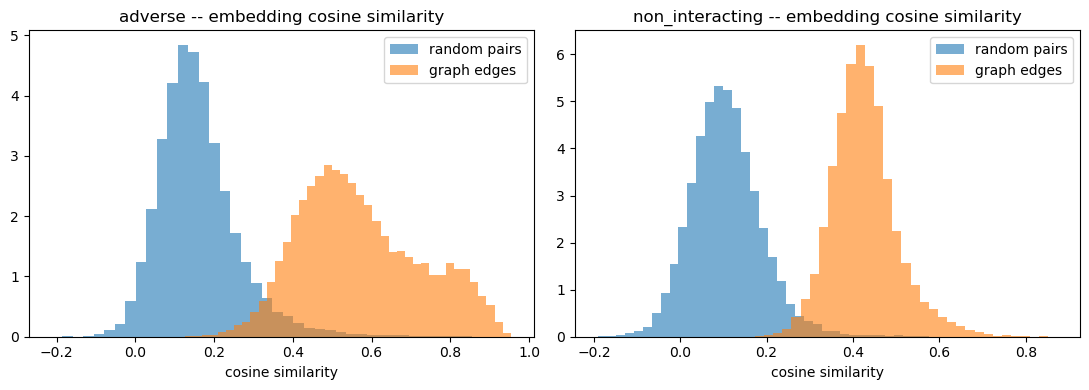

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, dataset in zip(axes, graphs):
    pos_sims, neg_sims = similarity_samples[dataset]
    ax.hist(neg_sims, bins=40, alpha=0.6, density=True, label="random pairs")
    ax.hist(pos_sims, bins=40, alpha=0.6, density=True, label="graph edges")
    ax.set_title(f"{dataset} -- embedding cosine similarity")
    ax.set_xlabel("cosine similarity")
    ax.legend()
plt.tight_layout()
plt.show()

## 7. Load the combined graph and train the canonical embedding (for downstream modeling)

The two embedding tables saved in Section 5 (`adverse_structural_node2vec.parquet`, `non_interacting_structural_node2vec.parquet`) are useful for the diagnostics above, but they **cannot** be used directly as classifier features: each came from a separately-trained node2vec model, and skip-gram embeddings have no canonical coordinate system -- two independent training runs converge to arbitrary, unaligned vector spaces. A classifier fed "adverse rows get vectors from model A, non_interacting rows get vectors from model B" could trivially separate the classes by detecting which arbitrary space a vector came from, not by learning real structural signal -- and at prediction time for a genuinely new pair, there's no way to know *which* graph's embedding to use without already knowing the label you're trying to predict.

The fix: `network_generation.ipynb` already built `combined_structural.graphml` from the union of both pair populations (edge weights are still just the raw, label-agnostic Tanimoto similarity score). We just load it here, train node2vec on it once, and save that as the single embedding table any downstream classifier notebook should load.

In [3]:
G_combined = nx.read_graphml(NETWORK_DIR / "combined_structural.graphml")

n_isolates = sum(1 for _, deg in G_combined.degree() if deg == 0)
print(f"Combined graph: {G_combined.number_of_nodes():,} nodes, {G_combined.number_of_edges():,} edges, "
      f"{n_isolates} isolate(s), density={nx.density(G_combined):.5f}")

Combined graph: 1,893 nodes, 20,904 edges, 1 isolate(s), density=0.01167


In [4]:
combined_embeddings = run_node2vec(G_combined, **NODE2VEC_PARAMS)
print(f"Combined embeddings shape: {combined_embeddings.shape}")

save_embeddings(combined_embeddings, EMBEDDING_DIR / "combined_structural_node2vec.parquet")
print(f"Saved to {EMBEDDING_DIR / 'combined_structural_node2vec.parquet'} -- use this file for any downstream classifier.")

KeyboardInterrupt: 

## 8. Sanity-check the combined embedding

Same checks as Sections 4 and 6, but run against `G_combined` / `combined_embeddings` -- this is the artifact downstream classifiers actually consume, so it should pass the same missing-node, PCA-collapse, nearest-neighbor, and edge-vs-random AUROC checks as the per-population embeddings did.

combined        : 0 node(s) missing an embedding (expect 0)


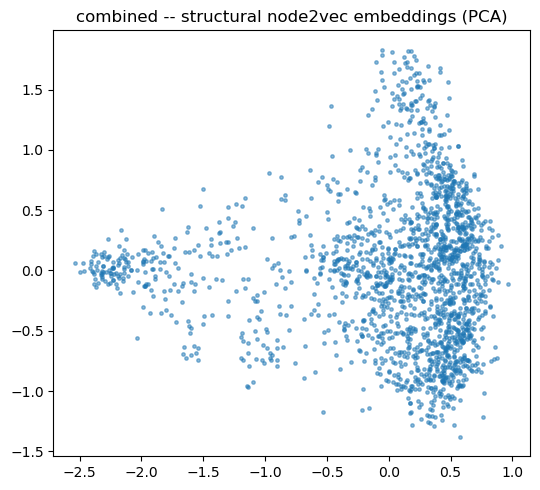


Nearest embedding neighbors of DB00454 (Meperidine):
  DB01081 (Diphenoxylate): cosine_sim=0.629, direct graph edge=True
  DB06738 (Ketobemidone): cosine_sim=0.584, direct graph edge=True
  DB01501 (Difenoxin): cosine_sim=0.584, direct graph edge=True
  DB08918 (Levomilnacipran): cosine_sim=0.483, direct graph edge=True
  DB01320 (Fosphenytoin): cosine_sim=0.480, direct graph edge=True

combined        : mean_cos_sim_edges=0.564, mean_cos_sim_random_pairs=0.155, auroc_edge_vs_random=0.988


In [12]:
n_missing = G_combined.number_of_nodes() - combined_embeddings.shape[0]
print(f"combined        : {n_missing} node(s) missing an embedding (expect 0)")

fig, ax = plt.subplots(figsize=(5.5, 5))
coords = PCA(n_components=2, random_state=42).fit_transform(combined_embeddings.values)
ax.scatter(coords[:, 0], coords[:, 1], s=6, alpha=0.5)
ax.set_title("combined -- structural node2vec embeddings (PCA)")
plt.tight_layout()
plt.show()

sample_node = max(G_combined.degree, key=lambda x: x[1])[0]  # pick a well-connected node so its neighbors are informative
sims = cosine_similarity(combined_embeddings.loc[[sample_node]], combined_embeddings).flatten()
nearest = pd.Series(sims, index=combined_embeddings.index).drop(sample_node).sort_values(ascending=False).head(5)

sample_name = G_combined.nodes[sample_node].get("name", sample_node)
print(f"\nNearest embedding neighbors of {sample_node} ({sample_name}):")
for neighbor_id, sim in nearest.items():
    is_graph_neighbor = G_combined.has_edge(sample_node, neighbor_id)
    neighbor_name = G_combined.nodes[neighbor_id].get("name", neighbor_id)
    print(f"  {neighbor_id} ({neighbor_name}): cosine_sim={sim:.3f}, direct graph edge={is_graph_neighbor}")

# edge-vs-random AUROC, same recipe as Section 6, scored against the combined graph's own edges
node_ids = list(combined_embeddings.index)
id_to_idx = {node_id: i for i, node_id in enumerate(node_ids)}
normed = combined_embeddings.values / np.linalg.norm(combined_embeddings.values, axis=1, keepdims=True)

edges = list(G_combined.edges())
pos_sims = np.array([normed[id_to_idx[u]] @ normed[id_to_idx[v]] for u, v in edges])

n_nodes = len(node_ids)
neg_sims = []
while len(neg_sims) < len(edges):
    i, j = rng.integers(0, n_nodes, size=2)
    if i == j:
        continue
    u, v = node_ids[i], node_ids[j]
    if G_combined.has_edge(u, v):
        continue
    neg_sims.append(normed[i] @ normed[j])
neg_sims = np.array(neg_sims)

y_true = np.concatenate([np.ones(len(pos_sims)), np.zeros(len(neg_sims))])
y_score = np.concatenate([pos_sims, neg_sims])

print(f"\ncombined        : mean_cos_sim_edges={pos_sims.mean():.3f}, "
      f"mean_cos_sim_random_pairs={neg_sims.mean():.3f}, "
      f"auroc_edge_vs_random={roc_auc_score(y_true, y_score):.3f}")

## Conclusions & recommendations (from the executed run)

### Conclusions

1. **node2vec clearly learned the graph structure, for both datasets.** `auroc_edge_vs_random` is **0.987** (adverse) and **0.995** (non_interacting) -- embedding cosine similarity almost perfectly separates real structural-similarity edges from random drug pairs, confirming the walk simulation + skip-gram training captured each graph's neighborhood structure and the embeddings are safe to use as downstream features.
2. **Unlike the H2 ATC graphs, the adverse and non_interacting structural graphs behave very similarly here.** Both have almost the same edge count (20,772 vs. 20,374, out of ~1,900 nodes each) and both produce a clean, single-peaked, well-separated histogram of edge-vs-random cosine similarities -- there's no sign of the fragmented/bimodal pattern seen for H2's non_interacting graph. This tracks with the structural-similarity network being built the same way (same sparsification settings) for both populations and ending up with comparable density, whereas the ATC layer's non_interacting graph was distinctly sparser than its adverse counterpart.
3. **Absolute cosine similarities are lower here than in H2** (mean edge similarity ~0.57 / 0.43 vs. ~0.88 / 0.71 for ATC), even though the AUROC separation is just as strong or stronger. This isn't a red flag by itself -- AUROC only cares about *relative* ranking of edges vs. non-edges, not the absolute similarity scale, and a denser graph (more edges per node here than in H2) naturally means each node's neighborhood -- and therefore its embedding -- is shaped by a more diverse set of neighbors, pulling absolute similarities down somewhat even when the *relative* separation stays sharp.
4. **This is a structural sanity check, not a DDI-predictiveness check** -- it confirms the embeddings faithfully encode *this graph's* edges, not that structural similarity itself is a good predictor of adverse DDIs. That question belongs in the downstream DDI modeling notebook.

### Recommendations

1. **For any downstream classifier, use `embeddings/combined_structural_node2vec.parquet` (Section 7)** -- not the two per-population tables above. Those are for diagnosing each population's graph topology/embedding quality in isolation; using them as classifier features would leak the label (see Section 7 for why).
2. Because both datasets embed comparably well here (unlike H2), there's no immediate need to retune `NODE2VEC_PARAMS` per-dataset for this hypothesis -- the shared paper-default hyperparameters look adequate for both.
3. Re-run this same Section 6 check after any future re-tuning of the structural-similarity graph's sparsification settings in `network_generation.ipynb`, or after changing `NODE2VEC_PARAMS` here -- a cheap way to catch a degenerate embedding run before spending time downstream.